# Código desenvolvido para baixar base de dados da NASA

## Importação de bibliotecas

In [2]:
from concurrent.futures import ThreadPoolExecutor
# from typing import Dict, Any
from tqdm import tqdm
import pandas as pd
import numpy as np
import glob
import json
# from math import sqrt
# from time import sleep

#from backend import pipeline
from shapely.geometry import Point
from shapely.ops import cascaded_union

import folium as fl
from shapely import wkt
import geopandas as gpd
import matplotlib.pyplot as plt

c:\Users\Lincon\anaconda3\envs\mmvenv\lib\site-packages\geopandas\_compat.py:123: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
C:\Users\Lincon\AppData\Local\Temp\ipykernel_12864\3710576862.py:17: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.rea

## Ler dados e plotar mapa

In [3]:
# # Lendo PB
# filename = 'https://raw.githubusercontent.com/CEARDados/mmp/master/Dados/PB_munic%C3%ADpios.json'
# sf = gpd.read_file(filename)
# sf.head(2)

# Lendo NE
filename = './grid_nordeste.csv'
df = pd.read_csv(filename)
sf = gpd.GeoDataFrame(df, geometry=df['geometry'].map(wkt.loads))
sf.head(2)

,center_point,envelope,NOME,geometry
0,POINT (-48.755 -5.349),"POLYGON ((-48.78 -5.3740000000000006, -48.7300...",S�o Pedro da �gua Branca,"POLYGON ((-48.74049 -5.35243, -48.75472 -5.348..."
1,POINT (-48.705 -5.349),"POLYGON ((-48.73 -5.3740000000000006, -48.68 -...",S�o Pedro da �gua Branca,"POLYGON ((-48.70403 -5.34434, -48.71169 -5.352..."


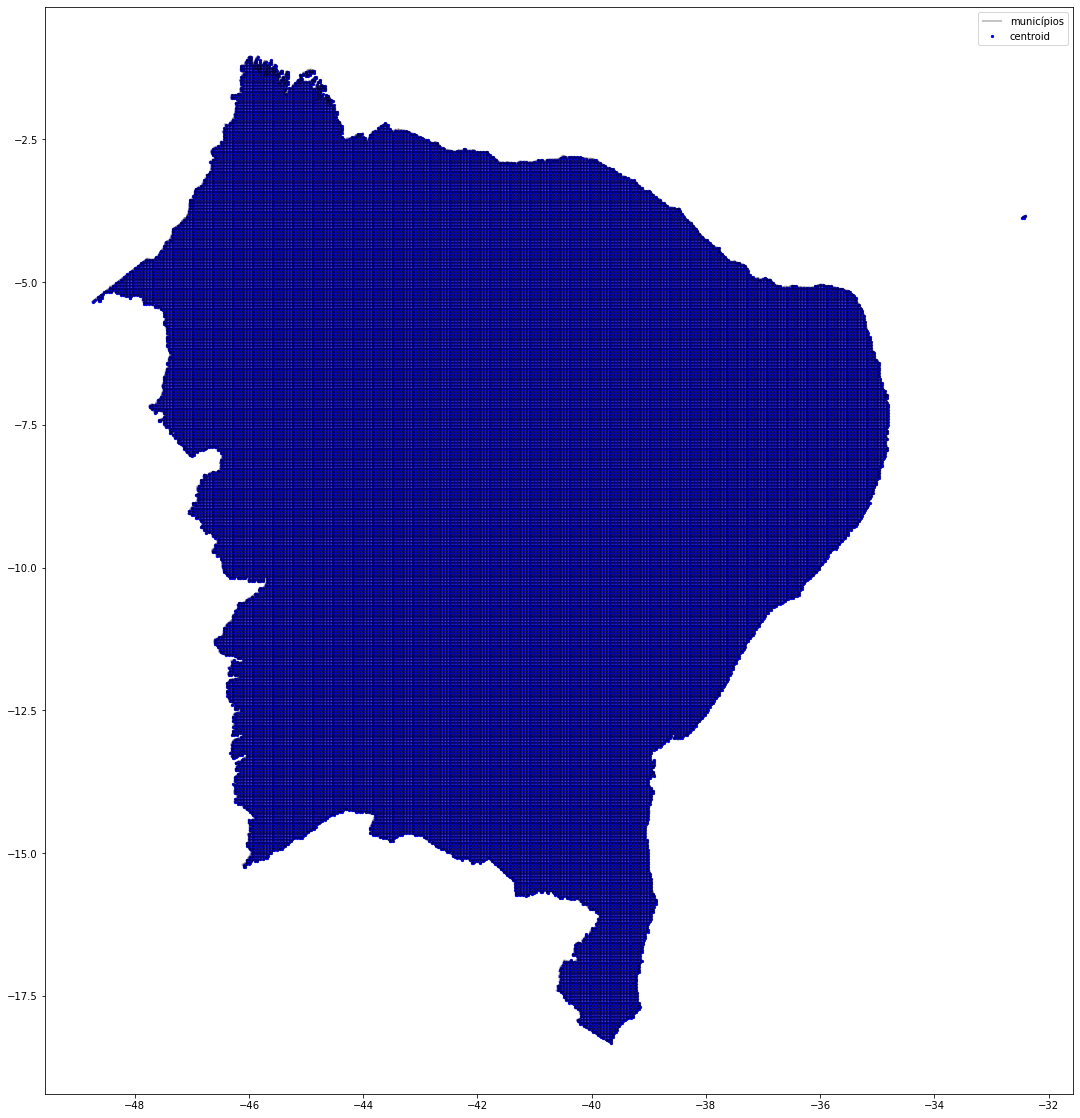

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
gpd.GeoSeries(sf['geometry']).plot(ax=ax, color='red', alpha=0.15)
gpd.GeoSeries(sf['geometry']).boundary.plot(ax=ax, color='black', label='municípios', alpha=0.30)
gpd.GeoSeries(sf['geometry']).centroid.plot(ax=ax, color='blue', label='centroid', alpha=1.00, markersize=5)
ax.legend()

## Gerar pontos de interesse e plota sobre o mapa

In [5]:
def gera_quadrados_simples(resolucao, shapefile_path) -> pd.DataFrame:

    if shapefile_path.endswith('.csv'):
        df = pd.read_csv(shapefile_path)
        sf = gpd.GeoDataFrame(df, geometry=df['geometry'].map(wkt.loads))
    else:
        sf = gpd.read_file(shapefile_path)

    lat_min = sf.bounds['miny'].min()
    long_min = sf.bounds['minx'].min()

    lat_max = sf.bounds['maxy'].max()
    long_max = sf.bounds['maxx'].max()

    list_longitude = [
        x for x in np.arange(long_min - 0.2*resolucao, long_max + 1.2*resolucao, resolucao)
    ]
    list_latitude = [
        x for x in np.arange(lat_min - 0.2*resolucao, lat_max + 1.2*resolucao, resolucao)
    ]

    list_coordenadas = []
    for x in list_longitude:
        for y in list_latitude:
            list_coordenadas.append(tuple([x, y]))

    list_Points = [Point(x) for x in list_coordenadas]
    gdf = gpd.GeoDataFrame(list_Points, columns=['center_point'])

    raio = resolucao/2
    gdf['envelope'] = [x.buffer(raio).envelope for x in gdf['center_point']]

    return gdf

In [6]:
resolucao=0.5
quadrados = gera_quadrados_simples(resolucao=resolucao, shapefile_path=filename)
quadrados.head(2)

,center_point,envelope
0,POINT (-48.85471684 -18.448939000000003),"POLYGON ((-49.10471684 -18.698939000000003, -4..."
1,POINT (-48.85471684 -17.948939000000003),"POLYGON ((-49.10471684 -18.198939000000003, -4..."


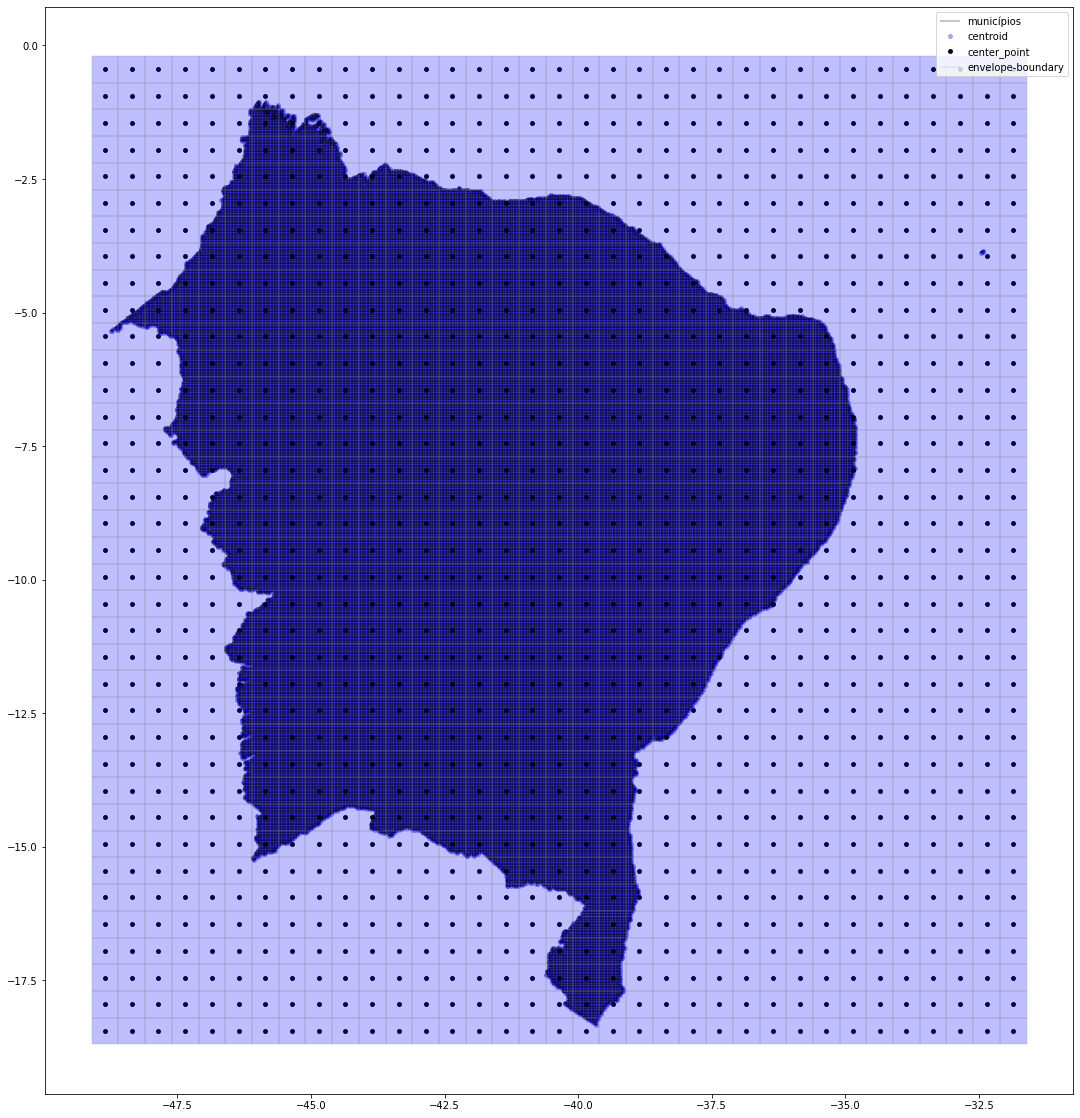

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
gpd.GeoSeries(sf['geometry']).plot(ax=ax, color='red', alpha=0.15)
gpd.GeoSeries(sf['geometry']).boundary.plot(ax=ax, color='black', label='municípios', alpha=0.30)
gpd.GeoSeries(sf['geometry']).centroid.plot(ax=ax, color='blue', label='centroid', alpha=0.30, markersize=15)

gpd.GeoSeries(quadrados['center_point']).plot(ax=ax, color='black', markersize=15, label='center_point')
gpd.GeoSeries(quadrados['envelope']).plot(ax=ax, color='blue', label='envelope', alpha=0.25)
gpd.GeoSeries(quadrados['envelope']).boundary.plot(ax=ax, color='gray', label='envelope-boundary', alpha=0.15)
ax.legend()

## Estratégia de redução de pontos

In [8]:
limites = gpd.GeoDataFrame(geometry=gpd.GeoSeries(cascaded_union(sf['geometry'])))
limites.head(2)

C:\Users\Lincon\AppData\Local\Temp\ipykernel_12864\1706893963.py:1: ShapelyDeprecationWarning: The 'cascaded_union()' function is deprecated. Use 'unary_union()' instead.
  limites = gpd.GeoDataFrame(geometry=gpd.GeoSeries(cascaded_union(sf['geometry'])))


,geometry
0,"MULTIPOLYGON (((-47.23000 -7.77400, -47.23000 ..."


<AxesSubplot:>

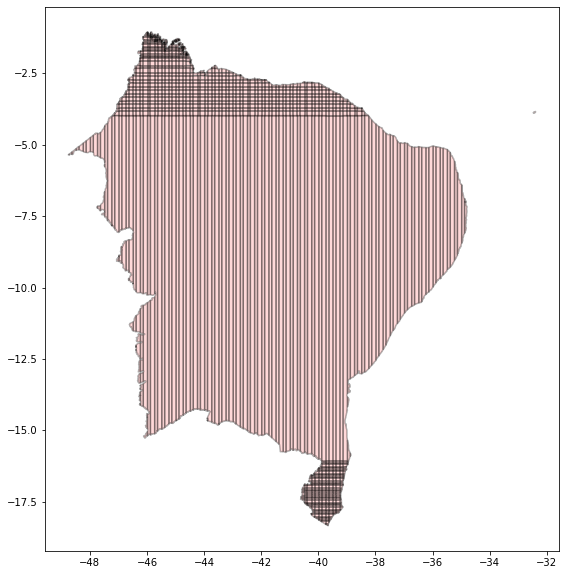

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
limites.plot(ax=ax, color='red', alpha=0.15)
limites.boundary.plot(ax=ax, color='black', label='Paraíba', alpha=0.30)

In [13]:
flag = [
    limites.distance(row['center_point'])[0] < 2 * resolucao
    for idx, row in quadrados.iterrows()
]
print(f'{sum(flag)} selecionados de um total de {len(flag)}.')

753 selecionados de um total de 1295.


In [14]:
quadrados_filtrado = quadrados.loc[flag].copy()
quadrados_filtrado.shape

(753, 2)

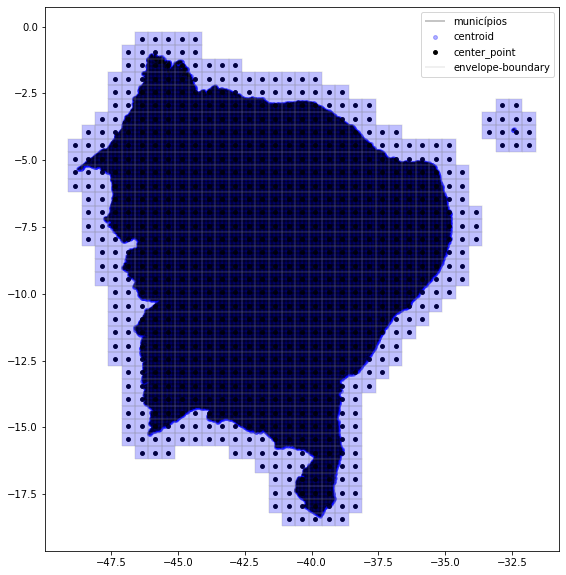

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
gpd.GeoSeries(sf['geometry']).plot(ax=ax, color='red', alpha=0.15)
gpd.GeoSeries(sf['geometry']).boundary.plot(ax=ax, color='black', label='municípios', alpha=0.30)
gpd.GeoSeries(sf['geometry']).centroid.plot(ax=ax, color='blue', label='centroid', alpha=0.30, markersize=15)

gpd.GeoSeries(quadrados_filtrado['center_point']).plot(ax=ax, color='black', markersize=15, label='center_point')
gpd.GeoSeries(quadrados_filtrado['envelope']).plot(ax=ax, color='blue', label='envelope', alpha=0.25)
gpd.GeoSeries(quadrados_filtrado['envelope']).boundary.plot(ax=ax, color='gray', label='envelope-boundary', alpha=0.15)
ax.legend()

## Mapa com a representação dos pontos de interesse

In [84]:
mapa = fl.Map(location=[-7.129694, -35.867750], zoom_start=7, tiles='OpenStreetMap')

for idx, row in quadrados_filtrado.iterrows():
    ponto = row['center_point']
    fl.CircleMarker(
        location=[ponto.y, ponto.x],
        radius=5,
        fill_color='red',
        popup='Ponto Nasa',
        name='Ponto Nasa',
        tooltip=f'<strong>Latitude:</strong> {ponto.y} <br><strong>Longitude:</strong> {ponto.x}'
    ).add_to(mapa)

mapa

## Download dos dados a partir do site POWER

In [91]:
data_inicial = 19830101
data_final = 20221230

with ThreadPoolExecutor(5) as pool:
    points = {(r['center_point'].y, r['center_point'].x) for i,r in quadrados.iterrows()}
    pbar = tqdm(total=len(points))
    futures = [
        (point, pool.submit(pipeline, lat_lon=point, start_date=data_inicial, end_date=data_final))
        for point in points
    ]
    for point, future in futures:
        while not future.done:
            sleep(0.5)
        e = future.exception()
        if e:
            pbar.write(str(e))
            f = pool.submit(pipeline, lat_lon=point, start_date=data_inicial, end_date=data_final)
            futures.append((point, f))
        else:
            pbar.update()

    pbar.close()


100%|██████████| 1295/1295 [1:01:42<00:00,  2.86s/it]


## Juntando todos os dados históricos em um dict de dicts: `dfs`

In [95]:
dfs = {}
paths = glob.glob('./pontos/histórico/*.json')

for path in paths:
    lat, lon = path.split('\\')[-1].replace('.json','').split('_')
    lat, lon = float(lat), float(lon)
    try:
        with open(path) as f:
            df = json.load(f)
        dfs[lat, lon] = df
    except Exception as e:
        print(path)

for key, value in dfs.items():
    print(f'key = {key}, value = {value}')

key = (-31.854716840000002, -0.44893900000000286), value = {'QV2M': 17.65264494489688, 'RH2M': 81.77600930933023, 'PS': 101.21163221301916, 'T2M': 26.54222054897665, 'T2M_MIN': 26.2380936409063, 'T2M_MAX': 26.80466082551851, 'WS10M': 5.6969409268259374, 'WS50M': 6.243753508111383, 'WS10M_MAX': 6.48399103292491, 'WS50M_MAX': 7.1531716749948355, 'WS10M_MIN': 4.8745567800670555, 'WS50M_MIN': 5.303547470737241, 'T2M_MIN_MINIMO': 23.89, 'T2M_MAX_MAXIMO': 29.18, 'WS10M_MAX_MAXIMO': 10.77, 'WS50M_MAX_MAXIMO': 12.1, 'WS10M_MIN_MINIMO': 0.02, 'WS50M_MIN_MINIMO': 0.01}
key = (-31.854716840000002, -0.9489390000000029), value = {'QV2M': 17.63191491546294, 'RH2M': 81.48005065370658, 'PS': 101.21352933123416, 'T2M': 26.583191868026663, 'T2M_MIN': 26.27979054007801, 'T2M_MAX': 26.843699774111855, 'WS10M': 5.811257444041337, 'WS50M': 6.378590252584031, 'WS10M_MAX': 6.592279759052657, 'WS50M_MAX': 7.283051543569008, 'WS10M_MIN': 4.994760763912652, 'WS50M_MIN': 5.442704497227752, 'T2M_MIN_MINIMO': 24.05

# Interpolando os dados mensais

In [4]:
def interpolate(lat, lon, date, columns, dfs:Dict[Any ,pd.DataFrame] , n, p=1):
    coordinates = list(dfs.keys())
    coordinates.sort(key=lambda x:sqrt((x[0]-lat)**2+(x[1]-lon)**2))
    row = {}
    for column in columns:
        sv = 0
        sw = 0
        for coordinate in coordinates[0:n]:
            w = 1 / sqrt((coordinate[0]-lat)**2 + abs(coordinate[1]-lon)**2)**p
            sw += w
            sv = dfs[coordinate].at[date, column] * w

        row[column] = sv/sw
    return row

def interpolate_historic(lat, lon, columns, dfs:Dict[Any, Dict] , n, p=1):
    coordinates = list(dfs.keys())
    coordinates.sort(key=lambda x:sqrt((x[0]-lat)**2+(x[1]-lon)**2))
    row = {}
    for column in columns:
        sv = 0
        sw = 0
        for coordinate in coordinates[0:n]:
            w = 1 / sqrt((coordinate[0]-lat)**2 + abs(coordinate[1]-lon)**2)**p
            sw += w
            sv = dfs[coordinate][column] * w

        row[column] = sv/sw
    return row

In [ ]:
columns = ['QV2M', 'RH2M', 'PS', 'T2M', 'T2M_MIN', 'T2M_MAX',
           'WS10M', 'WS50M', 'WS10M_MAX', 'WS50M_MAX', 'WS10M_MIN',
           'WS50M_MIN', 'T2M_MIN_MINIMO', 'T2M_MAX_MAXIMO',
           'WS10M_MAX_MAXIMO', 'WS50M_MAX_MAXIMO', 'WS10M_MIN_MINIMO',
           'WS50M_MIN_MINIMO']

grid = gera_quadrados(resolucao=0.05)

dates = list(pd.to_datetime(list(dfs.values())[0].index))
rows = list(grid.iterrows())

futures = []
for index, row in tqdm(rows):
    lat = row['centroid'].x
    lon = row['centroid'].y
    data = []
    result = pd.DataFrame()
    for date in dates:
        r = interpolate(lat, lon, date, columns, dfs, 4)
        rd = row.to_dict()
        r.update(rd, Date=date)
        data.append(r)
        result = pd.DataFrame(data=data)
        result = result.set_index('Date')
    result.to_csv(f'interpolados/{lat}_{lon}.csv', index_label='Date')

In [6]:
columns = ['QV2M', 'RH2M', 'PS', 'T2M', 'T2M_MIN', 'T2M_MAX',
           'WS10M', 'WS50M', 'WS10M_MAX', 'WS50M_MAX', 'WS10M_MIN',
           'WS50M_MIN', 'T2M_MIN_MINIMO', 'T2M_MAX_MAXIMO',
           'WS10M_MAX_MAXIMO', 'WS50M_MAX_MAXIMO', 'WS10M_MIN_MINIMO',
           'WS50M_MIN_MINIMO']

grid = gera_quadrados(resolucao=0.05)

rows = list(grid.iterrows())

futures = []
data = []
for index, row in tqdm(rows):
    lat = row['centroid'].x
    lon = row['centroid'].y
    r = interpolate_historic(lat, lon, columns, dfs, 4)
    rd = row.to_dict()
    r.update(rd)
    data.append(r)
pd.DataFrame(data=data).to_csv(f'interpolados_historico.csv')

100%|██████████| 2056/2056 [00:00<00:00, 4773.77it/s]


In [ ]:
dfs = {}
paths = glob.glob('./pontos/histórico/*.json')

import json

for path in paths:
    lat, lon = path.split('\\')[-1].replace('.json','').split('_')
    lat, lon = float(lat), float(lon)

    with open(path) as f:
        df = json.load(f)
    df.update(POINT=Point((lon, lat)))
